Label distribution:
label
1    42891
0    39595
Name: count, dtype: int64


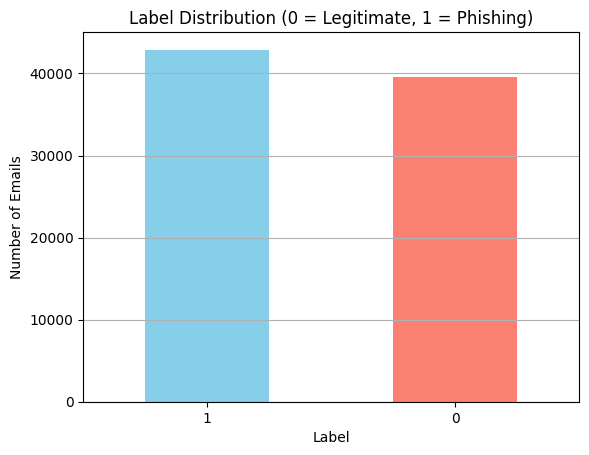

Training samples: 74237
Test samples: 8249
TF-IDF feature matrix (train): (74237, 5000)
TF-IDF feature matrix (test): (8249, 5000)


In [6]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("phishing_email.csv")

# Check label distribution
label_counts = df['label'].value_counts()
print("Label distribution:")
print(label_counts)

# Visualize the label distribution
label_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Label Distribution (0 = Legitimate, 1 = Phishing)")
plt.xlabel("Label")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()




from sklearn.model_selection import train_test_split

# Feature (email text) and label
X = df['text_combined']   # Raw email content
y = df['label']           # 0 = legitimate, 1 = phishing

# Split the dataset into training (90%) and test (10%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))




from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the vectorizer
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000  # limit to top 5000 words
)

# Fit on training data only
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the test data using the same vectorizer
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF feature matrix (train):", X_train_tfidf.shape)
print("TF-IDF feature matrix (test):", X_test_tfidf.shape)



In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Improved Random Forest Classifier with regularization to prevent overfitting
rf = RandomForestClassifier(
    n_estimators=100,         # number of trees
    max_depth=15,             # limit tree depth
    max_samples=0.8,          # use 80% of training samples
    max_features='sqrt',      # sqrt of total features
    bootstrap=True,           # bootstrap sampling
    class_weight='balanced',  # handle class imbalance
    random_state=42
)


# Perform 5-fold cross-validation on training set
scores = cross_val_score(rf, X_train_tfidf, y_train, cv=5, scoring='f1')

print("F1 scores from each fold:", scores)
print("Average F1 score:", np.mean(scores))


F1 scores from each fold: [0.953155   0.95413548 0.95488674 0.95084909 0.95510518]
Average F1 score: 0.9536262970467988


In [ ]:
### Cross-Validation Result

To evaluate the generalization performance of the model, 5-fold cross-validation was conducted on the training set using the F1-score. This approach helps assess the model's stability and robustness before applying it to unseen test data.


In [8]:
# ===============================
# Train the final model on the full training data
# ===============================
rf.fit(X_train_tfidf, y_train)

# ===============================
# Predict on the test data
# ===============================
y_pred = rf.predict(X_test_tfidf)

# ===============================
# Evaluate the results
# ===============================
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0     0.9655    0.9336    0.9493      3960
           1     0.9405    0.9692    0.9546      4289

    accuracy                         0.9521      8249
   macro avg     0.9530    0.9514    0.9520      8249
weighted avg     0.9525    0.9521    0.9521      8249

Confusion Matrix:

[[3697  263]
 [ 132 4157]]


In [9]:
from sklearn.metrics import roc_auc_score

# Predict probability scores for the positive class
y_proba = rf.predict_proba(X_test_tfidf)[:, 1]  # take probability of class 1

# Print AUC-ROC
print("AUC-ROC score:", roc_auc_score(y_test, y_proba))


AUC-ROC score: 0.9885254091391885


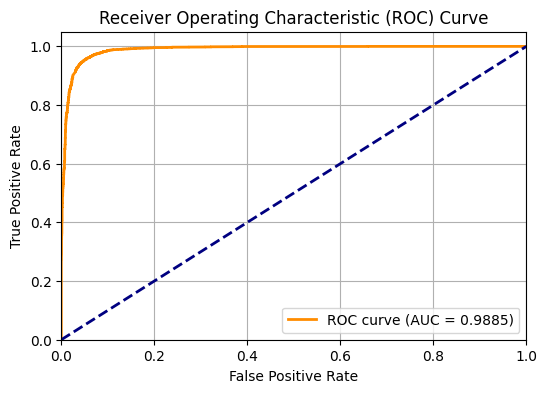

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Compute FPR, TPR
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Plot the ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [ ]:
### ✅ Model Evaluation Summary

- **Accuracy**: 0.9521
- **Macro Avg F1-score**: 0.9520
- **AUC-ROC Score**: 0.9885
- **Confusion Matrix**:
  [[3697, 263],
   [ 132, 4157]]


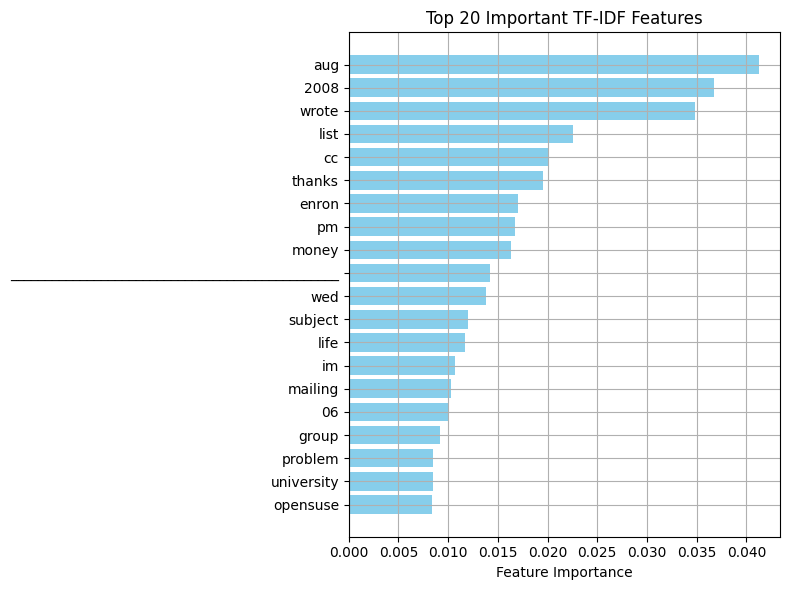

In [11]:
# Plot Top 20 Important Features from TF-IDF in Random Forest
import numpy as np
import matplotlib.pyplot as plt

# Get feature importance and names
importances = rf.feature_importances_
feature_names = vectorizer.get_feature_names_out()
indices = np.argsort(importances)[-20:]  # Top 20 important features

# Plot
plt.figure(figsize=(8, 6))
plt.barh(range(len(indices)), importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 20 Important TF-IDF Features")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
### 🔍 Analysis of Top 20 Important Features

The **most influential words** for detecting phishing emails include:

- **"aug", "2008", "wrote"** — These may reflect patterns from archived or dated scam emails, or specific spam campaigns.
- **"enron", "money", "thanks"** — These keywords are often found in financial scams or corporate fraud-related emails.

Understanding such patterns can help improve **email filtering**, guide **future feature engineering**, and enhance the interpretability of machine learning models for phishing detection.


In [ ]:
### 🧾 Final Summary

This project demonstrates the effectiveness of a Random Forest classifier in detecting phishing emails using TF-IDF features. The model achieved:

- High accuracy (**95.21%**) and macro average F1-score (**95.20%**) on the test set,
- AUC-ROC score of **0.9885**, indicating excellent discriminative ability,
- Balanced precision and recall, as shown in the confusion matrix.

By analyzing the top TF-IDF features, we also identified key terms frequently associated with phishing, such as **"money"**, **"wrote"**, and **"enron"**. These insights can assist in building more interpretable and robust email filtering systems in real-world applications.

✅ Overall, the model performs robustly and generalizes well, making it a strong candidate for practical deployment in phishing detection scenarios.
